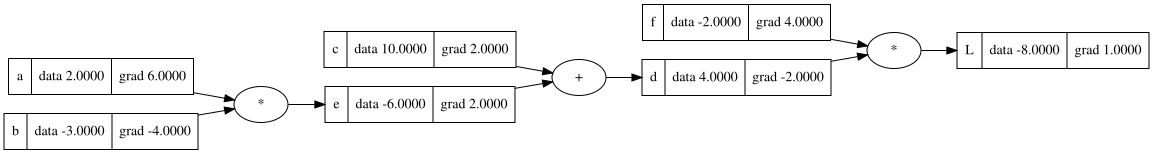

In [65]:
#Implementation of micrograd
import math as Math


class Value:
    def __init__(self,data,_children=(),_op='',label=''):
        self.data = data
        self._prev = set(_children)
        self.grad = 0
        self._op = _op
        self.label = label
        self._backward = lambda: None

    def __repr__(self):
        return f"Value(data:{self.data})"


    def __add__(self, other):
        other = other if isinstance(other,Value) else Value(other)
        out = Value(self.data + other.data,(self, other),'+')
        def _backward():
          self.grad += 1.0 * out.grad
          other.grad += 1.0 * out.grad
        out._backward = _backward
        return out

    def __sub__(self,other):
        return self + (-other)

    def __truediv__(self,other):
      return self * other**-1

    def __mul__(self, other):
        other = other if isinstance(other,Value) else Value(other)
        out = Value(self.data * other.data,(self, other),'*')
        def _backward():
          self.grad += other.data * out.grad
          other.grad += self.data * out.grad
        out._backward = _backward
        return out


    def __rmul__(self,other):
      return self * other

    def __pow__(self, other):
      assert isinstance(other, (int,float)) #supporting int/foat powers
      out = Value(self.data**other,(self,),f'**{other}')
      def _backward():
        self.grad += other * (self.data**(other - 1)) * out.grad
      out._backward = _backward
      return out
    def exp(self):
      x = self.data
      out = Value(Math.exp(x),(self,),'exp')
      def _backward():
        self.grad += out.data * out.grad
      out._backward = _backward
      return out


    def tanh(self):
      x = self.data
      t = (Math.exp(2*x)-1)/(Math.exp(2*x)+1)
      out = Value(t,(self,),'tanh')
      def _backward():
        self.grad += (1-t**2) * out.grad
      out._backward = _backward
      return out


    def backward(self):
      topo = []
      visited = set()
      def topo_build(v):
        if v not in visited:
          visited.add(v)
          for child in v._prev:
            topo_build(child)
          topo.append(v)
      topo_build(self)
      self.grad = 1.0
      for node in reversed(topo):
        node._backward()



from graphviz import Digraph
def trace(root):
    #builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child,v))
                build(child)
    build(root)
    return nodes, edges
def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir':'LR'}) # left to right

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        dot.node(name = uid,label="{ %s | data %.4f | grad %.4f}" % (n.label,n.data,n.grad), shape="record")
        if n._op:
            dot.node(name = uid + n._op,label=n._op)
            dot.edge(uid + n._op, uid)

    for n1,n2 in edges:
        dot.edge(str(id(n1)),str(id(n2)) + n2._op)

    return dot
a = Value(2,label='a')
b = Value(-3,label='b')
c = Value(10,label='c')
f = Value(-2,label='f')
e = b*a
e.label = 'e'
d = e + c
d.label = 'd'
L = d * f
L.label = 'L'
L.grad = 1.0
d.grad = -2.0
f.grad = 4.0
c.grad = 2.0
e.grad = 2.0
a.grad = 6.0
b.grad = -4.0
draw_dot(L)
# print(d)
# print(d._prev)
# print(d._op)
# d.grad = 1







In [ ]:
def grad():
  h = 0.001
  a = Value(2,label='a')
  b = Value(-3,label='b')
  c = Value(10,label='c')
  f = Value(-2,label='f')
  e = b*a
  d = e + c
  L = d * f
  L1 = L.data

  a = Value(-2,label='a')
  b = Value(3,label='b')
  c = Value(10,label='c')
  f = Value(-2, label='f')
  f.data += h
  e = b*a
  d = e + c
  L = d * f
  L2 = L.data

  print((L2-L1)/h)
grad()

3.9999999999995595


In [ ]:
dn = 1 - n.data**2
dn

0.012464156303938823

In [ ]:
#inputs
x1 = Value(2.0,label='x1')
x2 = Value(0.0,label='x2')
#weights
w1 = Value(-3.0,label='w1')
w2 = Value(1.0,label='w2')
#bias
b = Value(6.8824656, label='b')

x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'

#output
t = x1w1x2w2 + b; t.label = 't'
# n = t.tanh(); n.label = 'n'


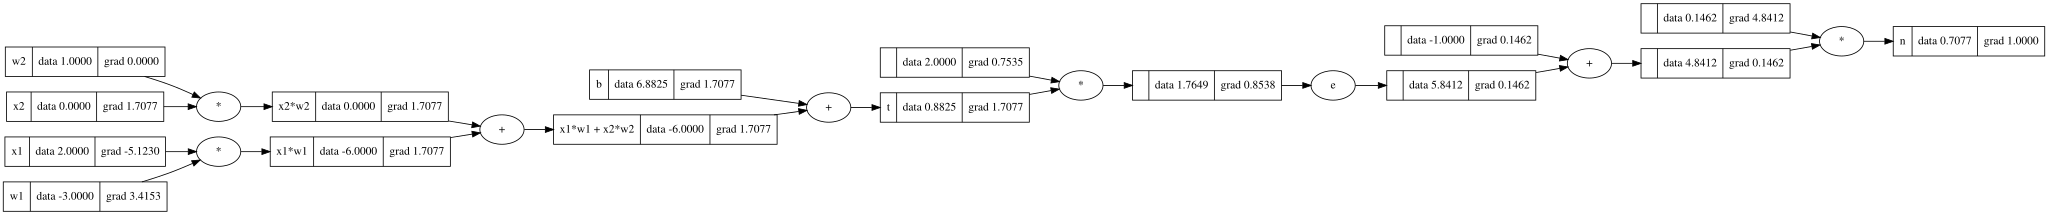

In [ ]:
e = (2*t).exp()
n = (e - 1) / (e + 1)
n.label = 'n'
n.backward()
draw_dot(n)

In [60]:
import random
class Neuron:
  def __init__(self, nin):
    self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
    self.b = Value(random.uniform(-1,1))
  def __call__(self, x):
     act = sum((wi*xi for wi,xi in zip(self.w,x)), self.b)
     out = act.tanh()
     return out
  def parameters(self):
    return self.w + [self.b]

class Layer:
  def __init__(self,nin,nout):
    self.neurons = [Neuron(nin) for _ in range(nout)]

  def __call__(self,x):
    outs = [n(x) for n in self.neurons]
    return outs[0] if len(outs) == 1 else outs
  def parameters(self):
    return [p for neuron in self.neurons for p in neuron.parameters()]
class MLP:
  def __init__(self,nin,nouts):
    sz = [nin] + nouts
    self.layers = [Layer(sz[i],sz[i+1]) for i in range(len(nouts))]
  def __call__(self,x):
    for layer in self.layers:
      x = layer(x)
    return x
  def parameters(self):
    return [p for layer in self.layers for p in layer.parameters()]

x = [2.0,3.0,-1.0]
n = MLP(3,[4,4,1])
n(x)


Value(data:-0.4041205698744575)

In [61]:
n.parameters()

[Value(data:-0.6808270483423424),
 Value(data:-0.8785932491358659),
 Value(data:-0.13862047387604814),
 Value(data:-0.41102652354046243),
 Value(data:0.602855330802438),
 Value(data:0.018661498288896183),
 Value(data:-0.0025545175434227296),
 Value(data:-0.9704848305463885),
 Value(data:-0.9296673507506013),
 Value(data:-0.5428842304062964),
 Value(data:-0.025242505019392958),
 Value(data:-0.4306238912898577),
 Value(data:-0.6286911280678835),
 Value(data:0.2679987539917472),
 Value(data:-0.720278583688233),
 Value(data:0.3004810531463489),
 Value(data:-0.6284988865201446),
 Value(data:-0.957499981246966),
 Value(data:-0.4619041658702867),
 Value(data:0.683509601824809),
 Value(data:0.15050900614784868),
 Value(data:0.9867208156606928),
 Value(data:-0.3710027197875696),
 Value(data:-0.961131117182574),
 Value(data:-0.44962587958523037),
 Value(data:-0.787101418965193),
 Value(data:0.28061728148662146),
 Value(data:-0.11080361702726083),
 Value(data:-0.7626529320139066),
 Value(data:-0.

In [62]:
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0]
]
ys = [1.0, -1.0, -1.0, 1.0]
ypred = [n(x) for x in xs]
ypred

[Value(data:-0.4041205698744575),
 Value(data:-0.5762930860029942),
 Value(data:-0.5322200913626466),
 Value(data:-0.4062812109913952)]

In [64]:
for k in range(20):

  # forward pass
  ypred = [n(x) for x in xs]
  loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))

  # backward pass
  for p in n.parameters():
    p.grad = 0.0
  loss.backward()

  # update
  for p in n.parameters():
    p.data += -0.1 * p.grad

  print(k, loss.data)

TypeError: unsupported operand type(s) for +: 'int' and 'Value'

In [53]:
loss.backward()

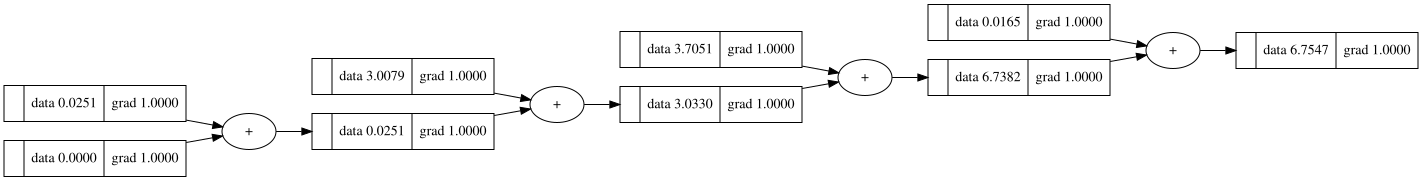

In [54]:
draw_dot(loss)

In [32]:
n.layers[0].neurons[0].w[0].grad

0

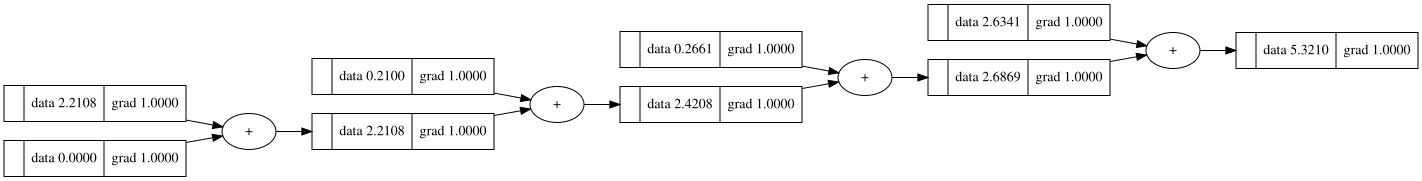

In [33]:
draw_dot(loss)

In [ ]:
n.grad = 1.0

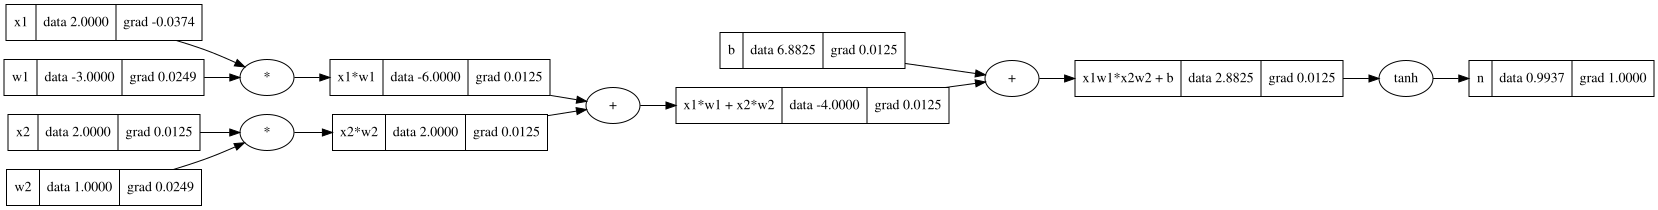

In [ ]:
n._backward()
t._backward()
x1w1x2w2._backward()
x1w1._backward()
x2w2._backward()
b._backward()
draw_dot(n)

In [ ]:
#topological sort
topo = []
visited = set()
def build_topo(v):
  if v not in visited:
    visited.add(v)
    for child in v._prev:
      build_topo(child)
    topo.append(v)
build_topo(n)


In [ ]:
t.grad = 1 - n.data**2

In [ ]:
x1w1x2w2.grad = b.data
b.grad = x1w1x2w2.data

In [ ]:
x1w1.grad = x2w2.data
x2w2.grad = x1w1.data

In [ ]:
x2.grad = w2.data
w2.grad = x2.data
x1.grad = w1.data
w1.grad = x1.data

In [ ]:
#n = tan(t)
#dn/dt = 1 - tan(t)**2